In [ ]:
!pip install psycopg2-binary pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 3.2 MB/s eta 0:00:0000:0100:010m


In [ ]:
import psycopg2
import pandas as pd

conn = psycopg2.connect(
    host="postgres",
    database=os.environ.get("POSTGRES_DB"),
    user=os.environ.get("POSTGRES_USER"),
    password=os.environ.get("POSTGRES_PASSWORD")
)

query = "SELECT * FROM orders LIMIT 10;"
df = pd.read_sql(query, conn)
df.head()


/tmp/ipykernel_3156/2306178236.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM orders", conn)


,id,created_at,product_name,category,price,quantity,city
0,1,2026-01-20 02:45:46.794233,Laptop,Electronics,864.98,1,Moscow
1,2,2026-01-20 02:45:47.802978,Headphones,Electronics,113.20,1,Paris
2,3,2026-01-20 02:45:48.804661,Phone,Electronics,550.08,2,Madrid
3,4,2026-01-20 02:45:49.806720,Laptop,Electronics,951.78,1,Rome
4,5,2026-01-20 02:45:50.816830,Sneakers,Fashion,141.68,3,Moscow


In [6]:
df['total_price'] = df['price'] * df['quantity']
df.groupby('category')['total_price'].sum()


category
Electronics    229530.09
Fashion         32553.38
Home            32505.54
Name: total_price, dtype: float64

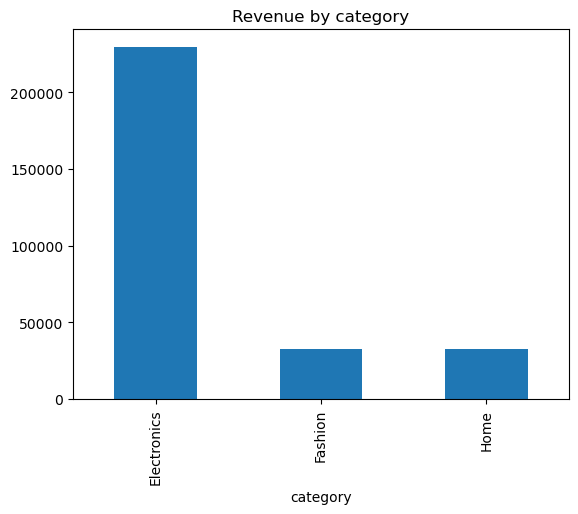

In [7]:
import matplotlib.pyplot as plt

df.groupby('category')['total_price'].sum().plot(kind='bar')
plt.title("Revenue by category")
plt.show()
